# 3. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* Use the **logistic regression**.
* Three different **validation methodologies** used to tune hyperparameters, discussing the pros and cons of each.
* **Confusion matrices** for your models, and associated comments.
 * Evaluate your models using the following metrics and provide associated comments for each:
   - **ROC curve**
   - **precision-recall curve**
   - **F1 score**
   - **accuracy**
   - **recall**
   - **precision**
* A discussion of which **performance metric** is most relevant for the evaluation of your models.

Please remember to provide associated comments for each metric; it is not enough to just provide the metric values.

In [64]:
#importing and splitting the data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option('display.max_columns', 1000)
data = pd.read_csv('secondary_data.csv')
from sklearn.model_selection import train_test_split
X = data.drop(columns=["class"])
y = data["class"]
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_val_data = X_train_val.copy()
train_val_data['class'] = y_train_val.copy()


In [66]:
# handling of missing values

train_val_data.isnull().sum()
missing_percent = train_val_data.isnull().mean() * 100
print("missing_percent")
print(missing_percent)
all = y_train_val.value_counts(normalize=True) * 100
print("all")
print(all)

rooted_stats = train_val_data[train_val_data['stem-root'].notna()]['class'].value_counts(normalize=True) * 100
print("stem-root")
print(rooted_stats)

analysis = train_val_data.groupby('stem-root')['class'].value_counts(normalize=True).unstack() * 100
print("analysis stem-root")
print(analysis)

spore_print_color = train_val_data[train_val_data['spore-print-color'].notna()]['class'].value_counts(normalize=True) * 100
print("spore-print-color")
display(spore_print_color)

analysis = train_val_data.groupby('spore-print-color')['class'].value_counts(normalize=True).unstack() * 100
print("analysis spore-print-color")
print(analysis)

veil_type = train_val_data[train_val_data['veil-type'].notna()]['class'].value_counts(normalize=True) * 100
print("veil-type")
display(veil_type)

analysis = train_val_data.groupby('veil-type')['class'].value_counts(normalize=True).unstack() * 100
print("analysis veil-type")
print(analysis)

veil_color = train_val_data[train_val_data['veil-color'].notna()]['class'].value_counts(normalize=True) * 100
print("veil-color")
display(veil_color) 

analysis = train_val_data.groupby('veil-color')['class'].value_counts(normalize=True).unstack() * 100
print("analysis veil-color")
print(analysis)

stem_surface = train_val_data[train_val_data['stem-surface'].notna()]['class'].value_counts(normalize=True) * 100
print("stem-surface")
display(stem_surface)

analysis = train_val_data.groupby('stem-surface')['class'].value_counts(normalize=True).unstack() * 100
print("analysis stem-surface")
print(analysis)








missing_percent
cap-diameter             0.000000
cap-shape                0.000000
cap-surface             23.094873
cap-color                0.000000
does-bruise-or-bleed     0.000000
gill-attachment         16.096612
gill-spacing            40.976359
gill-color               0.000000
stem-height              0.000000
stem-width               0.000000
stem-root               84.333231
stem-surface            62.405076
stem-color               0.000000
veil-type               94.753863
veil-color              87.900931
has-ring                 0.000000
ring-type                3.962747
spore-print-color       89.636680
habitat                  0.000000
season                   0.000000
class                    0.000000
dtype: float64
all
class
p    55.490738
e    44.509262
Name: proportion, dtype: float64
stem-root
class
p    62.581657
e    37.418343
Name: proportion, dtype: float64
analysis stem-root
class              e           p
stem-root                       
b          67.3421

class
p    72.150899
e    27.849101
Name: proportion, dtype: float64

analysis spore-print-color
class                       e           p
spore-print-color                        
g                  100.000000         NaN
k                   16.646849   83.353151
n                         NaN  100.000000
p                   27.992087   72.007913
r                         NaN  100.000000
u                         NaN  100.000000
w                   58.659794   41.340206
veil-type


class
p    66.835739
e    33.164261
Name: proportion, dtype: float64

analysis veil-type
class              e          p
veil-type                      
u          33.164261  66.835739
veil-color


class
p    57.215361
e    42.784639
Name: proportion, dtype: float64

analysis veil-color
class                e           p
veil-color                        
e                  NaN  100.000000
k                  NaN  100.000000
n                  NaN  100.000000
u                  NaN  100.000000
w            48.392979   51.607021
y           100.000000         NaN
stem-surface


class
p    62.998857
e    37.001143
Name: proportion, dtype: float64

analysis stem-surface
class                 e           p
stem-surface                       
f                   NaN  100.000000
g                   NaN  100.000000
h                   NaN  100.000000
i             36.306640   63.693360
k             32.992126   67.007874
s             58.597938   41.402062
t             47.273589   52.726411
y             32.089363   67.910637


In [67]:
X_train_val=X_train_val.drop(columns=["veil-type"])
X_train_val= X_train_val.fillna('missing')

Text(0.5, 1.0, 'stem-width')

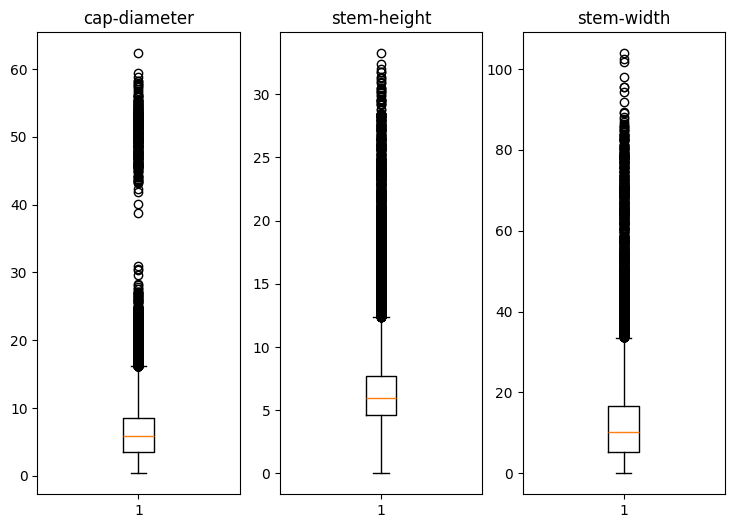

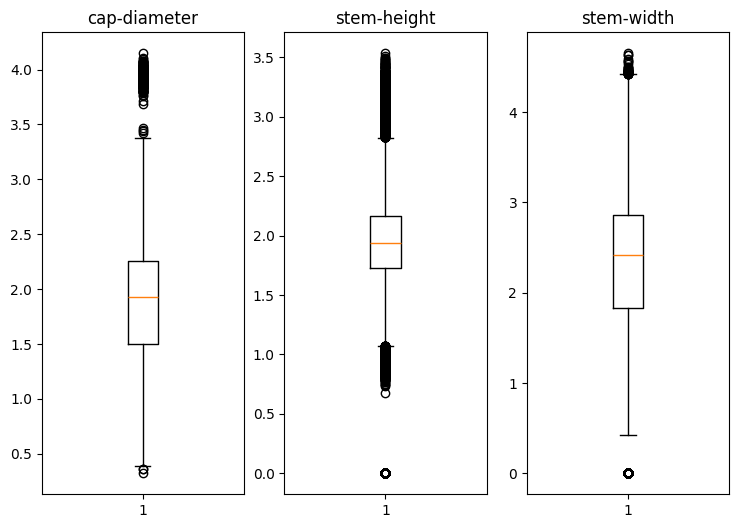

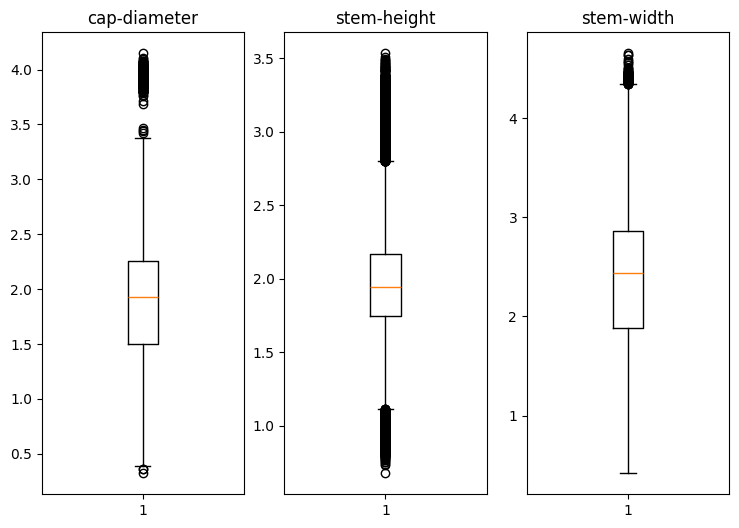

In [68]:
# outliers

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.boxplot(train_val_data["cap-diameter"])
plt.title("cap-diameter")

plt.subplot(1, 4, 2)
plt.boxplot(train_val_data["stem-height"])
plt.title("stem-height")

plt.subplot(1, 4, 3)
plt.boxplot(train_val_data["stem-width"])
plt.title("stem-width")

X_train_val["cap-diameter"] = X_train_val["cap-diameter"].apply(lambda x: np.log1p(x))
X_train_val["stem-height"] = X_train_val["stem-height"].apply(lambda x: np.log1p(x))
X_train_val["stem-width"] = X_train_val["stem-width"].apply(lambda x: np.log1p(x))

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.boxplot(X_train_val["cap-diameter"])
plt.title("cap-diameter")

plt.subplot(1, 4, 2)
plt.boxplot(X_train_val["stem-height"])
plt.title("stem-height")

plt.subplot(1, 4, 3)
plt.boxplot(X_train_val["stem-width"])
plt.title("stem-width")

# zeros = X_train_val[(X_train_val['stem-width']==0)]
# print(zeros)
# zeros2 = X_train_val[(X_train_val['stem-height']==0)]
# print(zeros2)

X_train_val['stem-height'] = X_train_val['stem-height'].replace(0, np.nan)
X_train_val['stem-width'] = X_train_val['stem-width'].replace(0, np.nan)

X_train_val['stem-height'] = X_train_val['stem-height'].fillna(X_train_val['stem-height'].median())
X_train_val['stem-width'] = X_train_val['stem-width'].fillna(X_train_val['stem-width'].median())

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.boxplot(X_train_val["cap-diameter"])
plt.title("cap-diameter")

plt.subplot(1, 4, 2)
plt.boxplot(X_train_val["stem-height"])
plt.title("stem-height")

plt.subplot(1, 4, 3)
plt.boxplot(X_train_val["stem-width"])
plt.title("stem-width")




In [69]:
# one-hot encoding
from sklearn.preprocessing import LabelEncoder
X_train_val = pd.get_dummies(X_train_val, columns=["cap-shape", "cap-surface", "cap-color", "does-bruise-or-bleed", "gill-attachment", "gill-spacing", "gill-color", "stem-root", "stem-surface", "stem-color", "veil-color", "has-ring", "ring-type", "spore-print-color", "habitat", "season"], drop_first=True)
le = LabelEncoder()
y_train_val = le.fit_transform(y_train_val)
X_train_val.head()

train_val_data = X_train_val.copy()
train_val_data['class'] = y_train_val.copy()


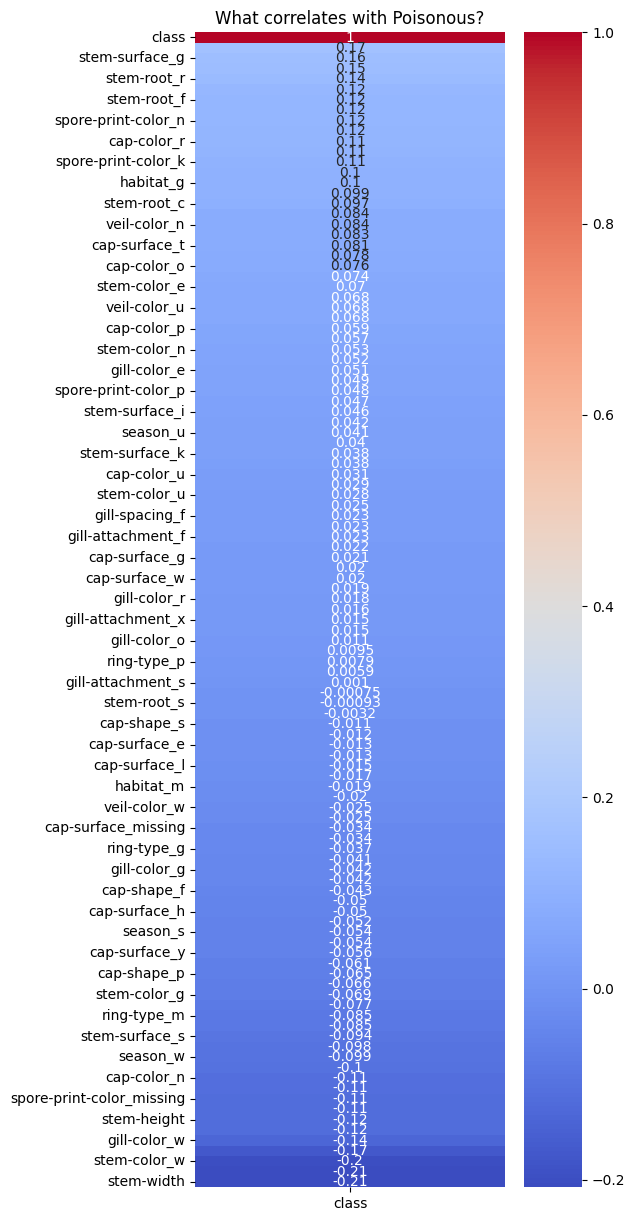

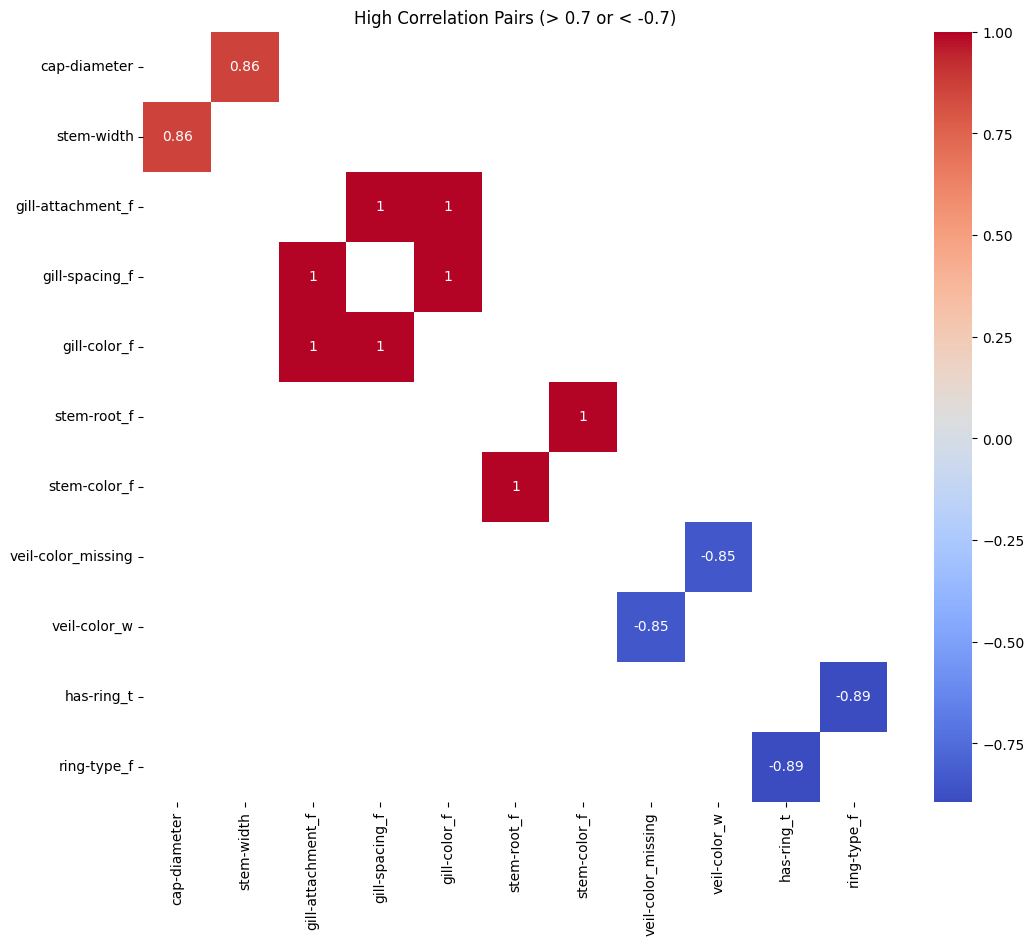

In [70]:
# correlation 

target_corr = train_val_data.corr()[['class']].sort_values(by='class', ascending=False)

plt.figure(figsize=(5, 15))
sns.heatmap(target_corr, annot=True, cmap="coolwarm")
plt.title("What correlates with Poisonous?")
plt.show()

corr = train_val_data.corr()

mask_self = np.eye(corr.shape[0]) == 0
corr_no_diag = corr.where(mask_self)

filtered_corr = corr_no_diag[((corr_no_diag >= 0.7) | (corr_no_diag <= -0.7))]

filtered_corr = filtered_corr.dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_corr, 
            annot=True, 
            cmap="coolwarm", 
           )

plt.title("High Correlation Pairs (> 0.7 or < -0.7)")
plt.show()

In [71]:
outliers = train_val_data[(train_val_data['has-ring_t'] == 1) & (train_val_data['ring-type_f'] == 1)]
print(f"Number of 'weird' mushrooms: {len(outliers)}")
print(outliers['class'].value_counts())

Number of 'weird' mushrooms: 1943
class
1    1668
0     275
Name: count, dtype: int64


In [72]:
print("Poisonous count for Missing Veil Color:")
print(train_val_data[train_val_data['veil-color_missing'] == 1]['class'].value_counts(normalize=True))

print("\nPoisonous count for White Veil Color:")
print(train_val_data[train_val_data['veil-color_w'] == 1]['class'].value_counts(normalize=True))

Poisonous count for Missing Veil Color:
class
1    0.552534
0    0.447466
Name: proportion, dtype: float64

Poisonous count for White Veil Color:
class
1    0.51607
0    0.48393
Name: proportion, dtype: float64


In [73]:
# correlation continuing

X_train_val = X_train_val.drop(columns=["gill-spacing_f", "gill-color_f", "stem-color_f", "veil-color_missing"])
X_train_val['diameter-and-width'] = X_train_val['cap-diameter'] * X_train_val['stem-width']
X_train_val = X_train_val.drop(columns=["cap-diameter", "stem-width"])
X_train_val.head()

,stem-height,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_missing,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_t,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_missing,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_d,gill-spacing_missing,gill-color_e,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-root_c,stem-root_f,stem-root_missing,stem-root_r,stem-root_s,stem-surface_g,stem-surface_h,stem-surface_i,stem-surface_k,stem-surface_missing,stem-surface_s,stem-surface_t,stem-surface_y,stem-color_e,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,veil-color_k,veil-color_n,veil-color_u,veil-color_w,veil-color_y,has-ring_t,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_missing,ring-type_p,ring-type_r,ring-type_z,spore-print-color_k,spore-print-color_missing,spore-print-color_n,spore-print-color_p,spore-print-color_r,spore-print-color_u,spore-print-color_w,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w,diameter-and-width
36219,1.978239,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,3.632181
54188,1.585145,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,4.496821
1609,2.468947,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,6.119637
20481,1.629241,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,3.003897
20546,

In [74]:
# Scaling
from sklearn.preprocessing import StandardScaler
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)

X_small = X_train_val.iloc[:3000]
y_small = y_train_val[:3000]

X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(X_small, y_small, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train[['diameter-and-width', 'stem-height']] = scaler.fit_transform(X_train[['diameter-and-width', 'stem-height']])
X_val[['diameter-and-width', 'stem-height']] = scaler.transform(X_val[['diameter-and-width', 'stem-height']])

scaler_small = StandardScaler()
X_train_small[['diameter-and-width', 'stem-height']] = scaler_small.fit_transform(X_train_small[['diameter-and-width', 'stem-height']])
X_test_small[['diameter-and-width', 'stem-height']] = scaler_small.transform(X_test_small[['diameter-and-width', 'stem-height']])




In [75]:
# Applying all changes to test set

X_test = X_test.drop(columns=["veil-type"])
X_test = X_test.fillna('missing')

X_test['stem-height'] = X_test['stem-height'].replace(0, np.nan)
X_test['stem-width'] = X_test['stem-width'].replace(0, np.nan)
X_test['stem-height'] = X_test['stem-height'].fillna(X_test['stem-height'].median())
X_test['stem-width'] = X_test['stem-width'].fillna(X_test['stem-width'].median())

X_test = pd.get_dummies(X_test, columns=["cap-shape", "cap-surface", "cap-color", "does-bruise-or-bleed", "gill-attachment", "gill-spacing", "gill-color", "stem-root", "stem-surface", "stem-color", "veil-color", "has-ring", "ring-type", "spore-print-color", "habitat", "season"], drop_first=True)
y_test = le.transform(y_test)

X_test["cap-diameter"] = X_test["cap-diameter"].apply(lambda x: np.log1p(x))
X_test["stem-height"] = X_test["stem-height"].apply(lambda x: np.log1p(x))
X_test["stem-width"] = X_test["stem-width"].apply(lambda x: np.log1p(x))

X_test = X_test.drop(columns=["gill-spacing_f", "gill-color_f", "stem-color_f", "veil-color_missing"])
X_test['diameter-and-width'] = X_test['cap-diameter'] * X_test['stem-width']
X_test = X_test.drop(columns=["cap-diameter", "stem-width"])

X_test[['diameter-and-width', 'stem-height']] = scaler.transform(X_test[['diameter-and-width', 'stem-height']])




c:\Users\piotr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Validation set - Accuracy: 0.8002, Precision: 0.7452, Recall: 0.9725, F1 score: 0.8438
Train set - Accuracy: 0.8053, Precision: 0.7496, Recall: 0.9747, F1 score: 0.8474
Confusion matrix:
[[2546 1803]
 [ 149 5273]]


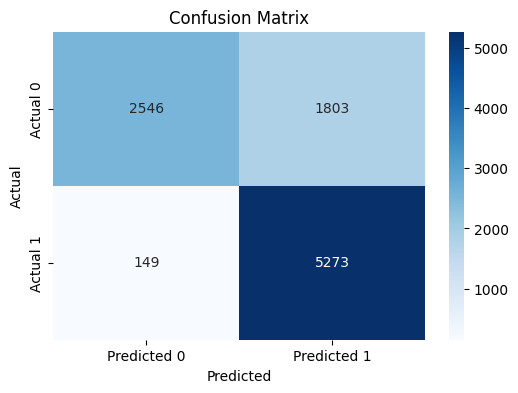

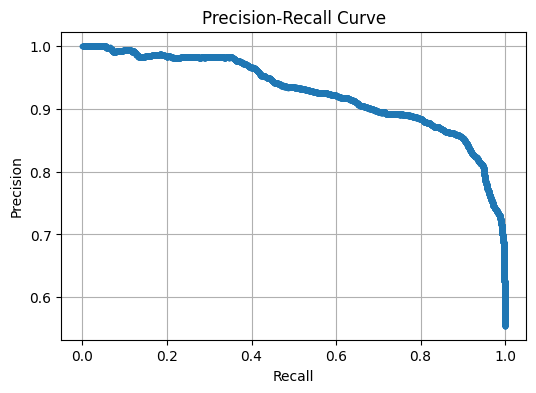

PR AUC: 0.9266


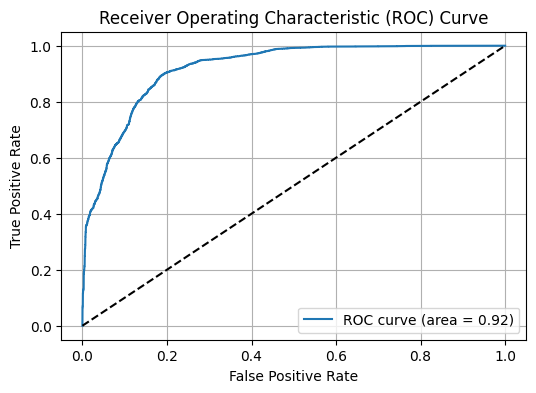

ROC AUC: 0.9198


In [76]:
# train val test validation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, auc

log_reg_1 = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="liblinear",
    class_weight={0: 1, 1: 4},
    max_iter=1000,
    random_state=42
)
log_reg_1.fit(X_train, y_train)

y_val_pred = log_reg_1.predict(X_val)
y_train_pred = log_reg_1.predict(X_train)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
print(f"Validation set - Accuracy: {val_accuracy:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1 score: {val_f1:.4f}")
print(f"Train set - Accuracy: {train_accuracy:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1 score: {train_f1:.4f}")

conf_matrix = confusion_matrix(y_val, y_val_pred)
fn = conf_matrix[1, 0]
print("Confusion matrix:")
print(conf_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

y_scores = log_reg_1.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker=".")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()
print(f"PR AUC: {pr_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()
print(f"ROC AUC: {roc_auc:.4f}")
# class 1 = poisonous, class 0 = edible.




CV Accuracy:  0.7793 (+/- 0.0014)
CV Precision: 0.7168 (+/- 0.0015)
CV Recall:    0.9957 (+/- 0.0013)
CV F1 score:  0.8335 (+/- 0.0009)
Confusion matrix (cross-validated predictions):
[[11080 10665]
 [  117 26993]]


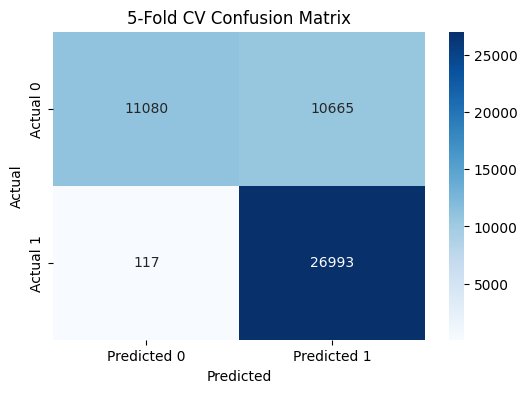

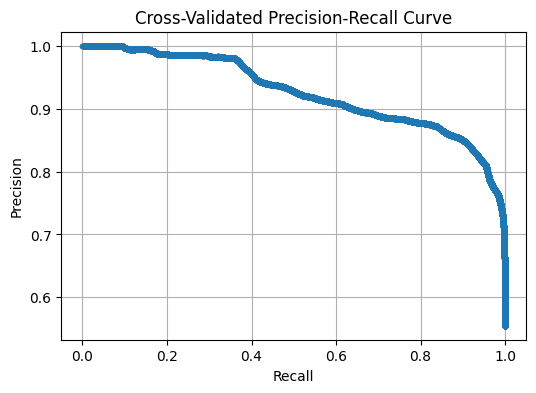

PR AUC: 0.9255


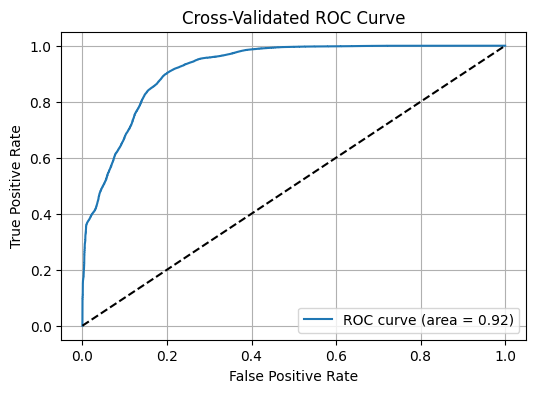

ROC AUC: 0.9198


In [77]:
# cross validation
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc
    )
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_2 = LogisticRegression(
    C=5.0,
    penalty="l1",
    solver="liblinear",
    class_weight={0: 1, 1: 8},
    max_iter=1000,
    random_state=42
)

accuracy_cv = cross_val_score(log_reg_2, X_train_val, y_train_val, cv=cv, scoring="accuracy", n_jobs=-1)
precision_cv = cross_val_score(log_reg_2, X_train_val, y_train_val, cv=cv, scoring="precision", n_jobs=-1)
recall_cv = cross_val_score(log_reg_2, X_train_val, y_train_val, cv=cv, scoring="recall", n_jobs=-1)
f1_cv = cross_val_score(log_reg_2, X_train_val, y_train_val, cv=cv, scoring="f1", n_jobs=-1)

print(f"CV Accuracy:  {accuracy_cv.mean():.4f} (+/- {accuracy_cv.std():.4f})")
print(f"CV Precision: {precision_cv.mean():.4f} (+/- {precision_cv.std():.4f})")
print(f"CV Recall:    {recall_cv.mean():.4f} (+/- {recall_cv.std():.4f})")
print(f"CV F1 score:  {f1_cv.mean():.4f} (+/- {f1_cv.std():.4f})")

y_cv_pred = cross_val_predict(log_reg_2, X_train_val, y_train_val, cv=cv, method="predict", n_jobs=-1)
y_cv_scores = cross_val_predict(log_reg_2, X_train_val, y_train_val, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

conf_matrix = confusion_matrix(y_train_val, y_cv_pred)
print("Confusion matrix (cross-validated predictions):")
print(conf_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("5-Fold CV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_train_val, y_cv_scores)
pr_auc = auc(recall_curve, precision_curve)
plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, marker=".")
plt.title("Cross-Validated Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()
print(f"PR AUC: {pr_auc:.4f}")

fpr, tpr, _ = roc_curve(y_train_val, y_cv_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Cross-Validated ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()
print(f"ROC AUC: {roc_auc:.4f}")



LOOCV metrics on X_train_small:
Accuracy:  0.5750 (+/- 0.4943)
Precision: 0.5637 (+/- 0.4959)
Recall:    0.5637 (+/- 0.4959)
F1 score:  0.5637 (+/- 0.4959)

LOOCV confusion matrix:
[[  27 1016]
 [   4 1353]]


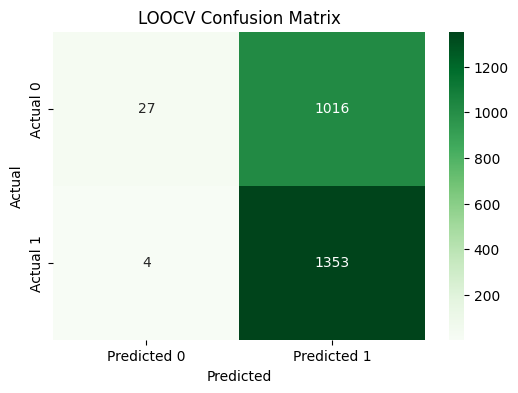

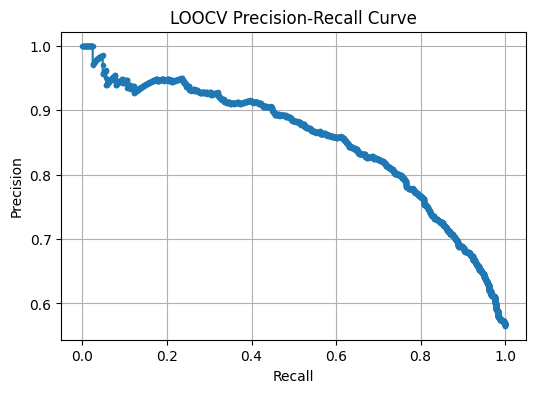

PR AUC: 0.8524


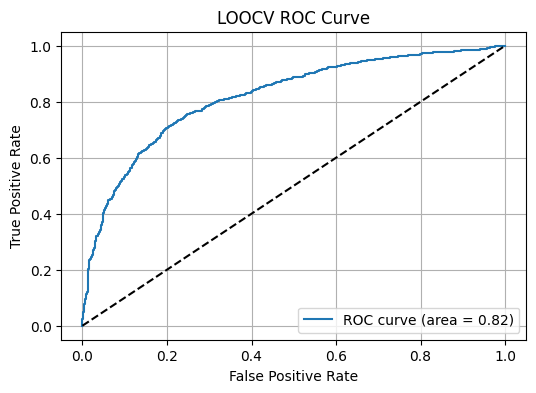

ROC AUC: 0.8185


In [78]:
# Leave-One-Out cross-validation
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc
    )
from sklearn.linear_model import LogisticRegression

loo = LeaveOneOut()

log_reg_3 = LogisticRegression(
    C=0.01,
    penalty="l2",
    solver="liblinear",
    class_weight={0: 1, 1: 4},
    max_iter=1000,
    random_state=42
)

loo_accuracy_scores = cross_val_score(log_reg_3, X_train_small, y_train_small, cv=loo, scoring="accuracy", n_jobs=-1)
loo_precision_scores = cross_val_score(log_reg_3, X_train_small, y_train_small, cv=loo, scoring="precision", n_jobs=-1)
loo_recall_scores = cross_val_score(log_reg_3, X_train_small, y_train_small, cv=loo, scoring="recall", n_jobs=-1)
loo_f1_scores = cross_val_score(log_reg_3, X_train_small, y_train_small, cv=loo, scoring="f1", n_jobs=-1)

print("LOOCV metrics on X_train_small:")
print(f"Accuracy:  {loo_accuracy_scores.mean():.4f} (+/- {loo_accuracy_scores.std():.4f})")
print(f"Precision: {loo_precision_scores.mean():.4f} (+/- {loo_precision_scores.std():.4f})")
print(f"Recall:    {loo_recall_scores.mean():.4f} (+/- {loo_recall_scores.std():.4f})")
print(f"F1 score:  {loo_f1_scores.mean():.4f} (+/- {loo_f1_scores.std():.4f})")


y_loo_pred = cross_val_predict(log_reg_3, X_train_small, y_train_small, cv=loo, method="predict", n_jobs=-1)
y_loo_scores = cross_val_predict(log_reg_3, X_train_small, y_train_small, cv=loo, method="predict_proba", n_jobs=-1)[:, 1]

loo_conf_matrix = confusion_matrix(y_train_small, y_loo_pred)
print("\nLOOCV confusion matrix:")
print(loo_conf_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(
    loo_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("LOOCV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_train_small, y_loo_scores)
pr_auc = auc(recall_curve, precision_curve)
plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, marker=".")
plt.title("LOOCV Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()
print(f"PR AUC: {pr_auc:.4f}")

fpr, tpr, _ = roc_curve(y_train_small, y_loo_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("LOOCV ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()
print(f"ROC AUC: {roc_auc:.4f}")



In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# model 1 on final test set
log_reg_1.fit(X_train, y_train)
y_test_pred_1 = log_reg_1.predict(X_test)
test_accuracy_1 = accuracy_score(y_test, y_test_pred_1)
test_precision_1 = precision_score(y_test, y_test_pred_1)
test_recall_1 = recall_score(y_test, y_test_pred_1)
test_f1_1 = f1_score(y_test, y_test_pred_1)
print(f"Test set model 1 - Accuracy: {test_accuracy_1:.4f}, Precision: {test_precision_1:.4f}, Recall: {test_recall_1:.4f}, F1 score: {test_f1_1:.4f}")

# model 2 on final test set
log_reg_2.fit(X_train_val, y_train_val)
y_test_pred_2 = log_reg_2.predict(X_test)
test_accuracy_2 = accuracy_score(y_test, y_test_pred_2)
test_precision_2 = precision_score(y_test, y_test_pred_2)
test_recall_2 = recall_score(y_test, y_test_pred_2)
test_f1_2 = f1_score(y_test, y_test_pred_2)
print(f"Test set model 2 - Accuracy: {test_accuracy_2:.4f}, Precision: {test_precision_2:.4f}, Recall: {test_recall_2:.4f}, F1 score: {test_f1_2:.4f}")

# model 3 on small final test set
log_reg_3.fit(X_train_small, y_train_small)
y_test_pred_3 = log_reg_3.predict(X_test_small)
test_accuracy_3 = accuracy_score(y_test_small, y_test_pred_3)
test_precision_3 = precision_score(y_test_small, y_test_pred_3)
test_recall_3 = recall_score(y_test_small, y_test_pred_3)
test_f1_3 = f1_score(y_test_small, y_test_pred_3)
print(f"Test set model 3 (small set) - Accuracy: {test_accuracy_3:.4f}, Precision: {test_precision_3:.4f}, Recall: {test_recall_3:.4f}, F1 score: {test_f1_3:.4f}")

c:\Users\piotr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Test set model 1 - Accuracy: 0.8046, Precision: 0.7475, Recall: 0.9783, F1 score: 0.8475


c:\Users\piotr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\piotr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Test set model 2 - Accuracy: 0.6769, Precision: 0.6320, Recall: 1.0000, F1 score: 0.7745
Test set model 3 (small set) - Accuracy: 0.5933, Precision: 0.5913, Recall: 1.0000, F1 score: 0.7432


c:\Users\piotr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
#1model - train val test validation
#2model - cross validation
#3model - leave one out validation
#Accuracy of the second model is worse than first 
#but it doesnt mean the second model is worse - in the 2 model i tried to maximize recall
#so that there are less amount of poisonous mushrooms predicted as edible
#which led also to having higher precision in the 1 model and lower in the second
#f1 score would be useful when both mistake predictions are important and i didnt put a lot of focus on that making those 2 models
#Precision-Recall curve: as threshold changes, precision and recall balance; higher PR AUC means a better model
#ROC curve: as threshold changes, TPR and FPR balance; higher ROC AUC means a better model.
#in model3 i chose only first 3000 data rows because of computational time
#because of that this this validation wasnt very good and all results were weak
#test set comparison: at the end the 1 model turned out to be the best because there is too much of a accuracy difference in model 2
#model3 test results are better but this is just pure luck

#validation pros and cons:
#train test val -> simple train and validation set easy to tune the model but one split can be lucky/unlucky depending
#cross validation -> in general better because we use more splits so result is less dependent on one lucky split, but at the end it can still be worse on final test set (like here with lower accuracy/precision) because i focused on recall too much
#leave-one-out -> uses almost all training rows each time, but is very slow and not reliable with the small subset i have to choose because of that

#the most important metric again is recall because we want to minimize false negatives